In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 7.1 MB/s eta 0:00:00


In [ ]:
from fastai.vision.all import *
import gradio as gr
import torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import cv2
import numpy as np
import kagglehub
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
import shutil


In [ ]:

path_str = kagglehub.dataset_download("msambare/fer2013")
path = Path(path_str)
train_path = path/'train'
valid_path = path/'test'

image_row, image_col = 48, 48
expression_classes = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
expression_enum = {exp: idx for idx, exp in enumerate(expression_classes)}

Train set expression counts:
       surprise  fear  angry  neutral   sad  disgust  happy
train      3171  4097   3995     4965  4830      436   7215

Test set expression counts:
Sample image for expression: surprise


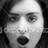

Sample image for expression: fear


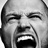

Sample image for expression: angry


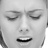

Sample image for expression: neutral


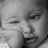

Sample image for expression: sad


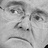

Sample image for expression: disgust


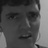

Sample image for expression: happy


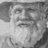

In [ ]:


def count_exp(path_obj, set_):
    dict_ = {}
    for expression in os.listdir(path_obj):
        dir_ = path_obj / expression
        if os.path.isdir(dir_):
            dict_[expression] = len(os.listdir(dir_))
    df = pd.DataFrame(dict_, index=[set_])
    return df

train_count = count_exp(train_path, 'train')
test_count = count_exp(valid_path, 'test')
print("Train set expression counts:")
print(train_count)
print("\nTest set expression counts:")


for expression in os.listdir(train_path):
    expression_dir = train_path / expression
    if os.path.isdir(expression_dir):
        images = get_image_files(expression_dir)
        if len(images) > 0:
            print(f"Sample image for expression: {expression}")
            display(Image.open(images[0]))

In [ ]:
class ExpressionDataset(torch.utils.data.Dataset):
    def __init__(self, path_dir):
        self.samples = []
        for label in os.listdir(path_dir):
            folder = path_dir / label
            if os.path.isdir(folder):
                for img_path in get_image_files(folder):
                    self.samples.append((img_path, expression_enum[label]))
        self.transform = transforms.Compose([
            transforms.Grayscale(),
            transforms.Resize((48, 48)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("L")
        return self.transform(image), label

train_ds = ExpressionDataset(train_path)
test_ds = ExpressionDataset(valid_path)
train_dl = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=64)

In [ ]:
# --- B.7: Weight Initialization ---
def initialize_weights(m):
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

In [ ]:
# --- CNN Model for Expression Classification ---
class CNNExpression(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 7)
        )

        self.apply(initialize_weights)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
model = CNNExpression()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

CNNExpression(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4608, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    

In [ ]:
# --- Train Function ---
def train_model(model, train_dl, num_epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    acc_history = []

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            correct += (pred.argmax(1) == yb).sum().item()
            total += xb.size(0)

        scheduler.step()

        epoch_loss = total_loss / total
        epoch_acc = correct / total
        loss_history.append(epoch_loss)
        acc_history.append(epoch_acc)

        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")

    # Plot loss and accuracy
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), loss_history, label='Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), acc_history, label='Accuracy', color='green')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Epoch 1: Loss = 1.7731, Accuracy = 0.2750
Epoch 2: Loss = 1.5506, Accuracy = 0.3979
Epoch 3: Loss = 1.4124, Accuracy = 0.4565
Epoch 4: Loss = 1.3307, Accuracy = 0.4880
Epoch 5: Loss = 1.2774, Accuracy = 0.5125
Epoch 6: Loss = 1.2285, Accuracy = 0.5306
Epoch 7: Loss = 1.1880, Accuracy = 0.5515
Epoch 8: Loss = 1.1579, Accuracy = 0.5652
Epoch 9: Loss = 1.1339, Accuracy = 0.5734
Epoch 10: Loss = 1.1094, Accuracy = 0.5828
Epoch 11: Loss = 1.0890, Accuracy = 0.5882
Epoch 12: Loss = 1.0701, Accuracy = 0.5951
Epoch 13: Loss = 1.0557, Accuracy = 0.6045
Epoch 14: Loss = 1.0362, Accuracy = 0.6078
Epoch 15: Loss = 1.0238, Accuracy = 0.6167
Epoch 16: Loss = 0.9589, Accuracy = 0.6393
Epoch 17: Loss = 0.9364, Accuracy = 0.6474
Epoch 18: Loss = 0.9284, Accuracy = 0.6498
Epoch 19: Loss = 0.9221, Accuracy = 0.6525
Epoch 20: Loss = 0.9177, Accuracy = 0.6499
Epoch 21: Loss = 0.9035, Accuracy = 0.6575
Epoch 22: Loss = 0.9025, Accuracy = 0.6569
Epoch 23: Loss = 0.9000, Accuracy = 0.6586
Epoch 24: Loss = 0.8

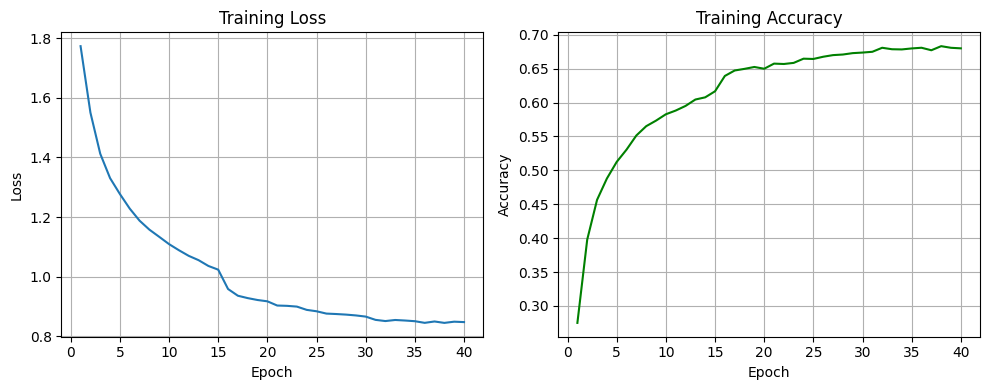

In [ ]:
train_model(model, train_dl, num_epochs=40, lr=1e-3)


In [ ]:
# --- Save Model ---
torch.save(model.state_dict(), "cnn_expression_model-v2.pth")
import pickle
with open("cnn_expression_model-v2.pkl", "wb") as f:
    pickle.dump(model, f)

In [ ]:
files.download("cnn_expression_model-v2.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=3096865acba1cd5eff76c2c41d125a6db5c11a2650056037e3835b5644f55c25
  Stored in directory: /root/.cache/pip/wheels/04/52/ec/9355da79c29f160b038a20c784db2803c2f9fa2c8a462c176a
Successfully built face-recognition-models


In [ ]:
# --- Gradio Inference Function ---
import face_recognition

def predict_expression(image):
    # Convert to RGB format which face_recognition expects
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    face_locations = face_recognition.face_locations(rgb_image)

    if len(face_locations) == 0:
        return image, "No human face detected."

    # Assume the first detected face is the one we care about
    top, right, bottom, left = face_locations[0]

    # Extract the face region
    # face_recognition uses (top, right, bottom, left) order for face_locations
    # OpenCV uses (y:y+h, x:x+w) for slicing
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    face_img = gray_image[top:bottom, left:right]

    face_img = cv2.resize(face_img, (48, 48))
    image_tensor = transforms.ToTensor()(face_img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        pred = torch.argmax(logits, dim=1).item()
    label = expression_classes[pred]

    image_with_box = image.copy()
    cv2.rectangle(image_with_box, (left, top), (right, bottom), (0,255,0), 2)

    return image_with_box, f"Predicted Expression: {label}"

# --- Select 5 sample images from test set ---
sample_images = []
for i in range(6):
    img_path, _ = test_ds.samples[i+1]
    sample_images.append(str(img_path))

In [ ]:
# --- Gradio App ---
demo = gr.Interface(
    fn=predict_expression,
    inputs=gr.Image(type="numpy", label="Upload Image"),
    outputs=[gr.Image(type="numpy", label="Processed Image"), gr.Textbox(label="Prediction")],
    examples=sample_images,
    title="Facial Expression Recognition",
    description="Upload people to find out their expressions. Images aside that will be labeled as no human, therefore will give the notification 'No human face detected.'. "
)
demo.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6bfb3ab16c145706fb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
